---
title: 2026-03-15 U-net example with Tessera and Torchgeo
date: "03/15/2026"
categories:
- phd
- tessera
image: ../assets/images/projects/phd-blog/2026-03-15-week.png
license: "CC BY"
copyright:
    holder: "Andrés C. Zúñiga-González"
    year: 2025
format: 
    html:
        code-fold: true
---

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../src')

This notebook presents a minimal example of how to create a deep learning model for classification of LCZ classes using Tessera embeddings and a couple of labels for Nairobi. It uses Torchgeo to handle dataloaders and [Sadiq's U-net](https://github.com/sadiqj/tessera-cnn-example) architecture for solar farm detection with a couple of tweaks on the loss because most of the ROI is not labeled.

In [2]:
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import geopandas as gpd
import rasterio
import rasterio.windows
from rasterio.merge import merge
from shapely.geometry import box as shapely_box

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from train_unet import UNet, MulticlassDiceLoss

## 1. Configuration

In [3]:
TIF_DIR    = '/maps/acz25/phd-thesis-data/input/Embeddings_test/GeoTessera/2017/'
LABEL_PATH = '/maps/acz25/phd-thesis-data/input/So2Sat-LCZ42/v4/patches_reference_Nairobi.gpkg'
LABEL_COL  = 'LCZ_class'

IN_CHANNELS = 128
NUM_CLASSES = 17
PATCH_SIZE  = 32    # pixels (320 m at 10 m/px)
BATCH_SIZE  = 16
EPOCHS      = 5
DICE_WEIGHT = 0.5

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cuda


In [4]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

lcz_dict = {
    1:  {"name": "Compact High-Rise",    "alt_code": "1",  "color": "#8c0000"},
    2:  {"name": "Compact Mid-Rise",     "alt_code": "2",  "color": "#d10000"},
    3:  {"name": "Compact Low-Rise",     "alt_code": "3",  "color": "#ff0000"},
    4:  {"name": "Open High-Rise",       "alt_code": "4",  "color": "#bf4d00"},
    5:  {"name": "Open Mid-Rise",        "alt_code": "5",  "color": "#ff6600"},
    6:  {"name": "Open Low-Rise",        "alt_code": "6",  "color": "#ff9955"},
    7:  {"name": "Lightweight Low-Rise", "alt_code": "7",  "color": "#faee05"},
    8:  {"name": "Large Low-Rise",       "alt_code": "8",  "color": "#bcbcbc"},
    9:  {"name": "Sparsely Built",       "alt_code": "9",  "color": "#ffccaa"},
    10: {"name": "Heavy Industry",       "alt_code": "10", "color": "#555555"},
    11: {"name": "Dense Trees",          "alt_code": "A",  "color": "#006a00"},
    12: {"name": "Scattered Trees",      "alt_code": "B",  "color": "#00aa00"},
    13: {"name": "Bush, Scrub",          "alt_code": "C",  "color": "#648525"},
    14: {"name": "Low Plants",           "alt_code": "D",  "color": "#b9db79"},
    15: {"name": "Bare Rock or Paved",   "alt_code": "E",  "color": "#000000"},
    16: {"name": "Bare Soil or Sand",    "alt_code": "F",  "color": "#fbf7ae"},
    17: {"name": "Water",               "alt_code": "G",  "color": "#6a6aff"},
}

# Colormap: index 0 = LCZ 1, ..., index 16 = LCZ 17
lcz_colors = [lcz_dict[c]['color'] for c in range(1, 18)]
lcz_cmap   = ListedColormap(lcz_colors, name='lcz')
lcz_norm   = BoundaryNorm(boundaries=np.arange(-0.5, 17.5, 1), ncolors=17)

def lcz_legend_handles():
    return [
        Patch(facecolor=lcz_dict[c]['color'],
              label=f"LCZ {lcz_dict[c]['alt_code']}: {lcz_dict[c]['name']}")
        for c in range(1, 18)
    ]

## 2. Build TIF Spatial Index

Read every TIF's bounding box into a GeoDataFrame.  
This lets us quickly look up which tiles cover any given polygon.

56 TIF tiles
CRS: EPSG:32737
resolution: (10.0, 10.0)
bands: 128


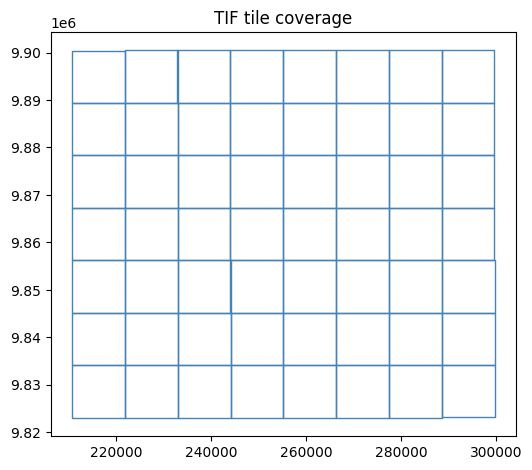

In [5]:
tif_paths = sorted(glob.glob(TIF_DIR + '*.tif'))
print(f'{len(tif_paths)} TIF tiles')

# Read CRS from the first tile
with rasterio.open(tif_paths[0]) as src:
    TIF_CRS = src.crs
    print('CRS:', TIF_CRS)
    print('resolution:', src.res)
    print('bands:', src.count)

records = []
for p in tif_paths:
    with rasterio.open(p) as src:
        records.append({'path': p, 'geometry': shapely_box(*src.bounds)})

tif_index = gpd.GeoDataFrame(records, crs=TIF_CRS)
tif_index.plot(figsize=(6, 6), edgecolor='steelblue', facecolor='none')
plt.title('TIF tile coverage')
plt.show()

## 3. Load Labels

So2Sat patches are 320 m × 320 m polygons (32 px at 10 m/px), each with a single LCZ class.  
The polygons **overlap** — adjacent patches share boundary pixels.  
We handle this by treating each polygon as an independent training sample,  
so overlaps never appear within a single patch.

Polygons: 4828  |  CRS: PROJCS["WGS 84 / UTM zone 37S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32737"]]
LCZ range: 1 - 17


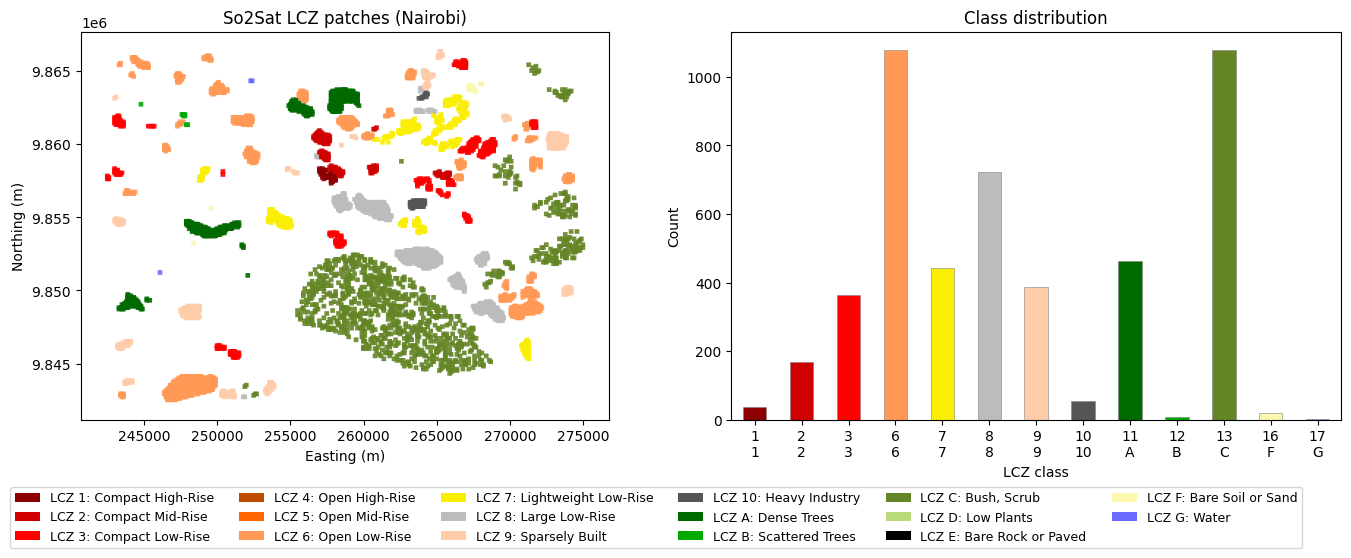

In [6]:
gdf_wgs84 = gpd.read_file(LABEL_PATH)
gdf = gdf_wgs84.to_crs(TIF_CRS)
print(f'Polygons: {len(gdf)}  |  CRS: {gdf.crs}')
print(f'LCZ range: {gdf[LABEL_COL].min()} - {gdf[LABEL_COL].max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Map: colour each polygon by its exact LCZ hex colour
gdf.plot(color=gdf[LABEL_COL].map(lambda c: lcz_dict[c]['color']), ax=axes[0], alpha=0.9)
axes[0].set_title('So2Sat LCZ patches (Nairobi)')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Bar chart: one bar per class, coloured with LCZ palette
counts = gdf[LABEL_COL].value_counts().sort_index()
bar_colors = [lcz_dict[c]['color'] for c in counts.index]
counts.plot.bar(ax=axes[1], color=bar_colors, edgecolor='grey', linewidth=0.4)
axes[1].set_title('Class distribution')
axes[1].set_xlabel('LCZ class')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(
    [f"{c}\n{lcz_dict[c]['alt_code']}" for c in counts.index], rotation=0
)

# Shared legend
fig.legend(handles=lcz_legend_handles(), fontsize=9, ncol=6,
           loc='lower center', bbox_to_anchor=(0.5, -0.12), framealpha=0.8)

plt.tight_layout()
plt.show()

## 4. Polygon Patch Dataset

Each item in the dataset is one So2Sat polygon:
- **image**: `(128, 32, 32)` Tessera embedding cropped to the polygon bounds  
- **mask**: `(32, 32)` filled with the polygon's LCZ class (0-indexed)

When a polygon crosses multiple TIF tiles, `rasterio.merge` mosaics them first.  
Overlapping polygons are not a problem — each is an independent sample.

In [7]:
class PolygonPatchDataset(Dataset):
    """One sample per So2Sat polygon: (128, 32, 32) embedding + (32, 32) class mask."""

    def __init__(self, gdf, tif_index, label_col, patch_size=32):
        self.gdf = gdf.reset_index(drop=True)
        self.tif_index = tif_index
        self.label_col = label_col
        self.patch_size = patch_size

    def __len__(self):
        return len(self.gdf)

    def __getitem__(self, idx):
        row = self.gdf.iloc[idx]
        bounds = row.geometry.bounds          # (minx, miny, maxx, maxy)
        label = int(row[self.label_col]) - 1  # 1-based -> 0-based

        covering = self.tif_index[self.tif_index.intersects(row.geometry)]
        import rasterio
        if covering.empty:
            image = torch.zeros(IN_CHANNELS, self.patch_size, self.patch_size)
        elif len(covering) == 1:
            
            with rasterio.open(covering.iloc[0]['path']) as src:
                win = rasterio.windows.from_bounds(*bounds, transform=src.transform)
                data = src.read(window=win, out_shape=(src.count, self.patch_size, self.patch_size),
                                resampling=rasterio.enums.Resampling.bilinear,
                                boundless=True, fill_value=0.0)
            image = torch.from_numpy(data.astype(np.float32))
        else:
            # Polygon spans multiple tiles — mosaic them first
            srcs = [rasterio.open(p) for p in covering['path']]
            mosaic, mosaic_transform = merge(srcs, bounds=bounds)
            for s in srcs:
                s.close()
            # Resize mosaic to fixed patch_size
            from rasterio.transform import from_bounds as tfm_from_bounds
            import rasterio.warp
            out = np.zeros((mosaic.shape[0], self.patch_size, self.patch_size), dtype=np.float32)
            dst_transform = tfm_from_bounds(*bounds, self.patch_size, self.patch_size)
            for b in range(mosaic.shape[0]):
                rasterio.warp.reproject(
                    source=mosaic[b].astype(np.float32),
                    destination=out[b],
                    src_transform=mosaic_transform,
                    src_crs=TIF_CRS,
                    dst_transform=dst_transform,
                    dst_crs=TIF_CRS,
                    resampling=rasterio.enums.Resampling.bilinear,
                )
            image = torch.from_numpy(out)

        mask = torch.full((self.patch_size, self.patch_size), label, dtype=torch.long)
        return image, mask

## 5. Train / Val Split

In [8]:
rng = np.random.default_rng(42)
perm = rng.permutation(len(gdf))
n_train = int(0.8 * len(gdf))

train_gdf = gdf.iloc[perm[:n_train]]
val_gdf   = gdf.iloc[perm[n_train:]]

train_ds = PolygonPatchDataset(train_gdf, tif_index, LABEL_COL, PATCH_SIZE)
val_ds   = PolygonPatchDataset(val_gdf,   tif_index, LABEL_COL, PATCH_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f'Train: {len(train_ds)}  |  Val: {len(val_ds)}')

# Sanity check
img, mask = train_ds[0]
print(f'image: {img.shape} {img.dtype}  |  mask: {mask.shape} {mask.dtype}  |  label: {mask[0,0].item()}')

Train: 3862  |  Val: 966
image: torch.Size([128, 32, 32]) torch.float32  |  mask: torch.Size([32, 32]) torch.int64  |  label: 6


### Visualise a batch

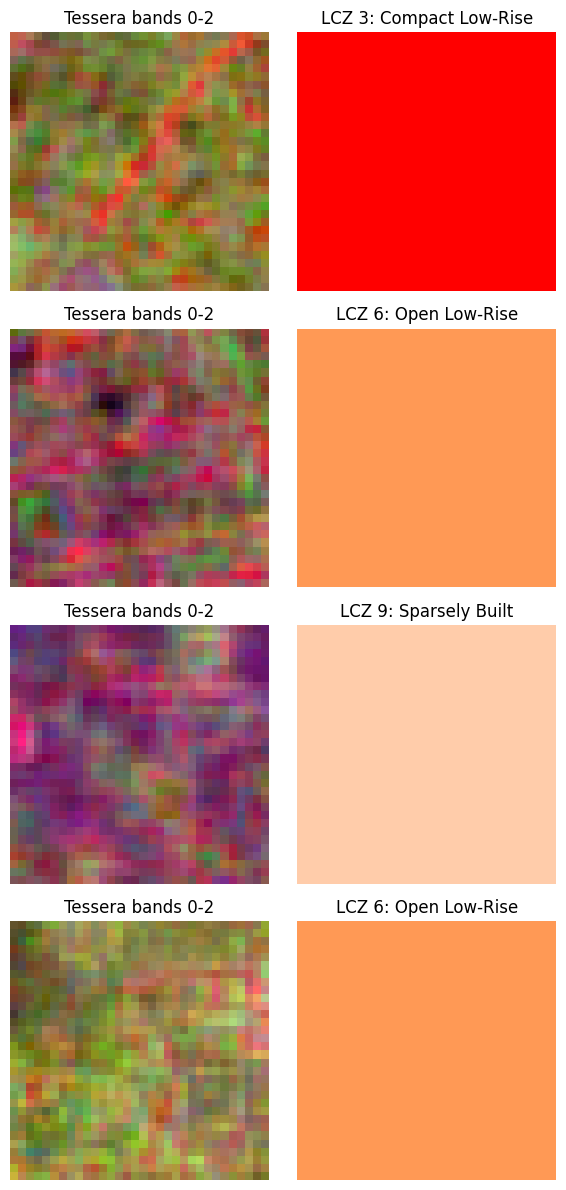

In [9]:
images, masks = next(iter(train_loader))
n_show = 4
fig, axes = plt.subplots(n_show, 2, figsize=(6, 3 * n_show))
for i in range(n_show):
    img = images[i, :3].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    cls = masks[i, 0, 0].item() + 1  # 0-indexed -> 1-indexed
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Tessera bands 0-2')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(masks[i].numpy(), cmap=lcz_cmap, norm=lcz_norm)
    axes[i, 1].set_title(f'LCZ {cls}: {lcz_dict[cls]["name"]}')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

## 6. UNet Model

Using the `UNet` from `train_unet.py` with the `small` preset `(depth=3, base=32)`.  
Available: `nano (2,8)`, `small (3,32)`, `base (3,48)`, `medium (4,32)`, `large (4,48)`.

In [10]:
PRESET = 'small'
depth, base_features = UNet.PRESETS[PRESET]

model = UNet(
    in_channels=IN_CHANNELS,
    num_classes=NUM_CLASSES,
    depth=depth,
    base_features=base_features,
    bottleneck_dropout=0.3,
).to(DEVICE)

print(f'Preset: {PRESET}  (depth={depth}, base={base_features})')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Preset: small  (depth=3, base=32)
Parameters: 1,963,537


## 7. Training Loop

Loss: `(1 − dice_weight) × CrossEntropy + dice_weight × MulticlassDice`  
`MulticlassDiceLoss` is macro-averaged over present classes, ignoring `ignore_index=-1`.

In [11]:
ce_loss   = nn.CrossEntropyLoss()
dice_loss = MulticlassDiceLoss(NUM_CLASSES)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def combined_loss(logits, masks):
    ce   = ce_loss(logits, masks)
    dice = dice_loss(logits, masks)
    return (1.0 - DICE_WEIGHT) * ce + DICE_WEIGHT * dice, ce, dice

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    t_loss = t_ce = t_dice = 0.0
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        loss, ce, dice = combined_loss(model(images), masks)
        loss.backward()
        optimizer.step()
        t_loss += loss.item(); t_ce += ce.item(); t_dice += dice.item()
    n = len(train_loader)
    t_loss /= n; t_ce /= n; t_dice /= n
    scheduler.step()

    # --- val ---
    model.eval()
    v_loss = v_ce = v_dice = 0.0
    correct = total = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss, ce, dice = combined_loss(logits, masks)
            v_loss += loss.item(); v_ce += ce.item(); v_dice += dice.item()
            preds = logits.argmax(dim=1)
            correct += (preds == masks).sum().item()
            total   += masks.numel()
    m = len(val_loader)
    v_loss /= m; v_ce /= m; v_dice /= m

    print(
        f'Epoch {epoch:02d}/{EPOCHS}'
        f'  train={t_loss:.4f} (ce={t_ce:.4f} dice={t_dice:.4f})'
        f'  val={v_loss:.4f} (ce={v_ce:.4f} dice={v_dice:.4f})'
        f'  val_acc={correct/total:.4f}'
    )

Epoch 01/5  train=0.8171 (ce=1.1119 dice=0.5223)  val=0.4026 (ce=0.5040 dice=0.3013)  val_acc=0.8433
Epoch 02/5  train=0.4562 (ce=0.6010 dice=0.3114)  val=0.3021 (ce=0.3795 dice=0.2247)  val_acc=0.8929
Epoch 03/5  train=0.3594 (ce=0.4779 dice=0.2409)  val=0.2186 (ce=0.2721 dice=0.1650)  val_acc=0.9143
Epoch 04/5  train=0.2891 (ce=0.3783 dice=0.1999)  val=0.1821 (ce=0.2249 dice=0.1394)  val_acc=0.9303
Epoch 05/5  train=0.2536 (ce=0.3308 dice=0.1763)  val=0.1641 (ce=0.2019 dice=0.1264)  val_acc=0.9421


## 8. Visualise Predictions

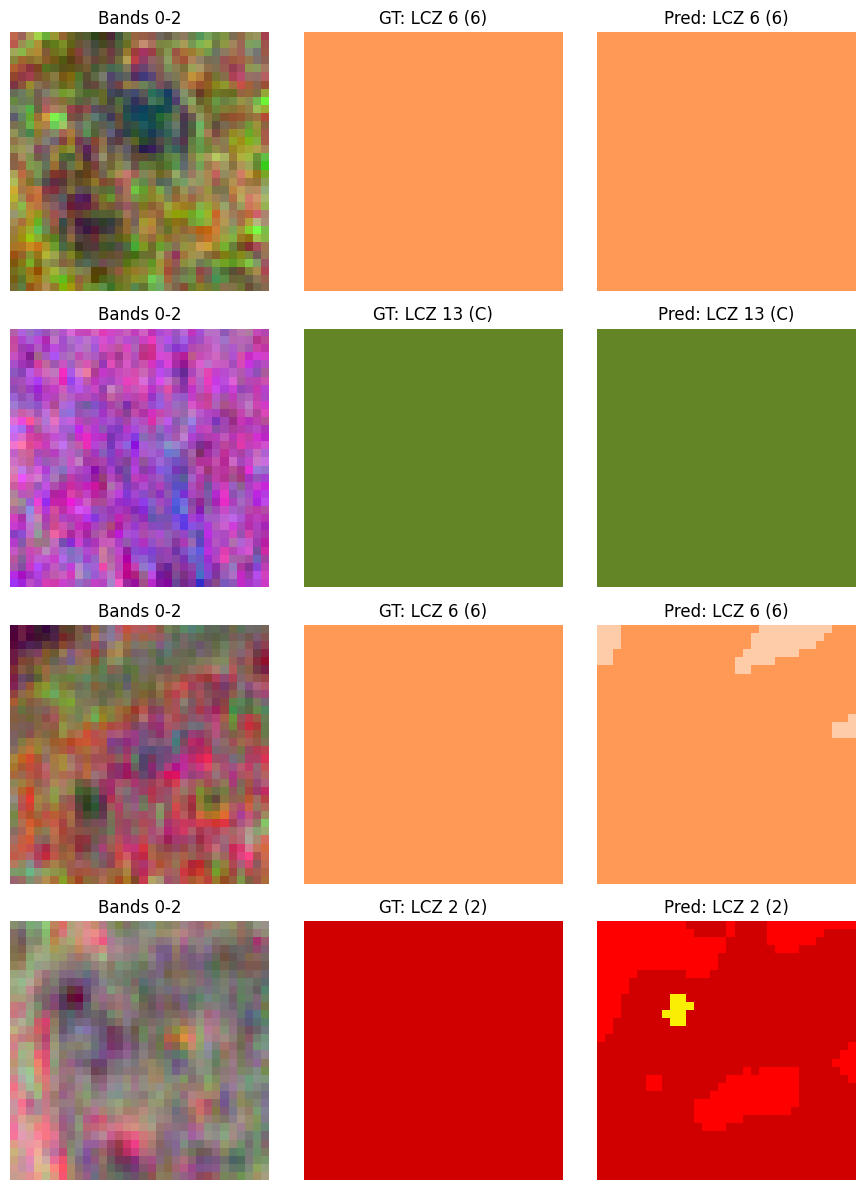

In [12]:
model.eval()
images, masks = next(iter(val_loader))
with torch.no_grad():
    preds = model(images.to(DEVICE)).argmax(dim=1).cpu()

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
for i in range(n_show):
    img = images[i, :3].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    gt_cls   = masks[i, 0, 0].item() + 1
    pred_cls = preds[i].flatten().mode().values.item() + 1
    axes[i, 0].imshow(img)
    axes[i, 0].set_title('Bands 0-2')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(masks[i].numpy(), cmap=lcz_cmap, norm=lcz_norm)
    axes[i, 1].set_title(f'GT: LCZ {gt_cls} ({lcz_dict[gt_cls]["alt_code"]})')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(preds[i].numpy(), cmap=lcz_cmap, norm=lcz_norm)
    axes[i, 2].set_title(f'Pred: LCZ {pred_cls} ({lcz_dict[pred_cls]["alt_code"]})')
    axes[i, 2].axis('off')
plt.tight_layout()
plt.show()

## 9. Full-ROI Prediction with torchgeo

Use torchgeo's `RasterDataset` + `GridGeoSampler` to tile the entire label area,  
run inference on each patch, then mosaic the results into a single prediction map.

In [13]:
from torchgeo.datasets import RasterDataset
from torchgeo.samplers import GridGeoSampler, Units
from torchgeo.datasets.utils import stack_samples

class TesseraDataset(RasterDataset):
    filename_glob = '*.tif'

tessera_ds = TesseraDataset(paths=TIF_DIR)
print(f'Tiles: {len(tessera_ds.index)}  CRS: {tessera_ds.crs}  res: {tessera_ds.res}')

# Restrict inference to the So2Sat label area
roi_minx, roi_miny, roi_maxx, roi_maxy = gdf.total_bounds
roi = shapely_box(roi_minx, roi_miny, roi_maxx, roi_maxy)

pred_sampler = GridGeoSampler(
    tessera_ds, size=PATCH_SIZE, stride=PATCH_SIZE, roi=roi, units=Units.PIXELS
)
print(f'Inference patches: {len(pred_sampler)}')

Tiles: 56  CRS: PROJCS["WGS 84 / UTM zone 37S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",39],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32737"]]  res: (10.0, 10.0)
Inference patches: 8008


In [14]:
def pred_collate(batch):
    # stack_samples handles stacking tensor fields; 'bounds' is a (9,) tensor per sample
    # -> stacked to (N, 9): [minx, maxx, xstep, miny, maxy, ystep, tmin, tmax, tstep]
    return stack_samples(batch)

pred_loader = DataLoader(
    tessera_ds, batch_size=BATCH_SIZE, sampler=pred_sampler,
    num_workers=4, collate_fn=pred_collate,
)

# Run inference, collect (pred_patch, minx, miny, maxx, maxy) per patch
model.eval()
patch_results = []  # list of (H, W) arrays with their spatial bbox
res = tessera_ds.res[0]  # scalar pixel size in CRS units

with torch.no_grad():
    for batch in pred_loader:
        logits = model(batch['image'].float().to(DEVICE))
        preds  = logits.argmax(dim=1).cpu().numpy()  # (N, H, W)
        bounds = batch['bounds']                     # (N, 9) tensor
        for i in range(preds.shape[0]):
            minx = float(bounds[i, 0])
            maxx = float(bounds[i, 1])
            miny = float(bounds[i, 3])
            maxy = float(bounds[i, 4])
            patch_results.append((preds[i], minx, miny, maxx, maxy))

print(f'Collected {len(patch_results)} patches')

Collected 8008 patches


Raster: 2441 × 3297 px  (24.4 × 33.0 km)


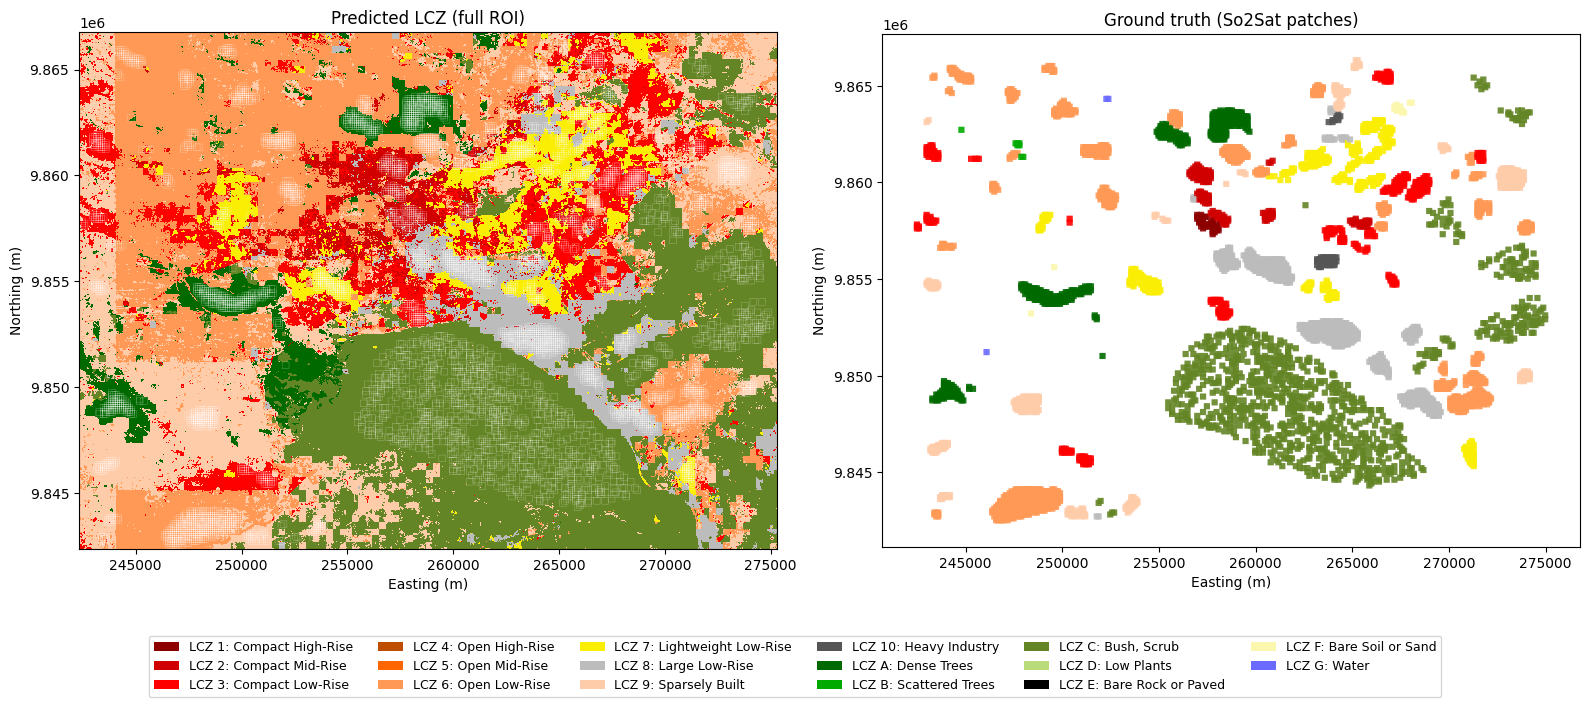

In [15]:
# Assemble patches into a full raster
all_minx = min(p[1] for p in patch_results)
all_miny = min(p[2] for p in patch_results)
all_maxx = max(p[3] for p in patch_results)
all_maxy = max(p[4] for p in patch_results)

out_w = int(round((all_maxx - all_minx) / res))
out_h = int(round((all_maxy - all_miny) / res))
raster = np.full((out_h, out_w), fill_value=-1, dtype=np.int16)

for pred, minx, miny, maxx, maxy in patch_results:
    col = int(round((minx - all_minx) / res))
    row = int(round((all_maxy - maxy) / res))
    ph, pw = pred.shape
    raster[row:row + ph, col:col + pw] = pred

print(f'Raster: {out_h} × {out_w} px  ({out_h * res / 1000:.1f} × {out_w * res / 1000:.1f} km)')

extent_utm = [all_minx, all_maxx, all_miny, all_maxy]
masked_raster = np.ma.masked_where(raster < 0, raster)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: predicted LCZ map
axes[0].imshow(masked_raster, cmap=lcz_cmap, norm=lcz_norm,
               extent=extent_utm, origin='upper', interpolation='nearest')
gdf.boundary.plot(ax=axes[0], color='white', linewidth=0.3, alpha=0.4)
axes[0].set_title('Predicted LCZ (full ROI)')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')

# Right: ground-truth labels
gdf.plot(color=gdf[LABEL_COL].map(lambda c: lcz_dict[c]['color']), ax=axes[1], alpha=0.9)
axes[1].set_title('Ground truth (So2Sat patches)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')

# Shared legend
fig.legend(handles=lcz_legend_handles(), fontsize=9, ncol=6,
           loc='lower center', bbox_to_anchor=(0.5, -0.09), framealpha=0.8)

plt.tight_layout()
plt.show()

## 10. Export Prediction to GeoTIFF

In [16]:
from rasterio.transform import from_bounds as rasterio_from_bounds

output_path = f'nairobi_lcz_{PRESET}_prediction.tif'

transform = rasterio_from_bounds(all_minx, all_miny, all_maxx, all_maxy, out_w, out_h)

# Write 1-indexed classes (0 = nodata) so the file is self-consistent with lcz_dict
export_raster = np.where(raster >= 0, raster + 1, 0).astype(np.uint8)

with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=out_h, width=out_w,
    count=1,
    dtype='uint8',
    crs=TIF_CRS,
    transform=transform,
    nodata=0,
) as dst:
    dst.write(export_raster, 1)

print(f'Saved: {output_path}  ({out_h}×{out_w} px, CRS={TIF_CRS.to_epsg()})')

Saved: nairobi_lcz_small_prediction.tif  (2441×3297 px, CRS=32737)
